Name	Sales Territory 1	Sales Territory 2	Region


Collins 	Florida	            South Carolina	    South

In [236]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

In [237]:
customerList = pd.read_csv('customer_list.csv', sep='|') # this somehow became an issue at the last possible moment even thought the merge later on worked fine without it
customerList.info()
print("\nfirst 5 rows:")
display(customerList.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB

first 5 rows:


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [238]:
productCategories = pd.read_csv('ProductCategories.csv')
productCategories.info()
print("\nfirst 5 rows:")
display(productCategories.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB

first 5 rows:


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [239]:
products = pd.read_csv('Products.csv')
products.info()
print("\nfirst 5 rows:")
display(products.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB

first 5 rows:


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [240]:
storeDetail = pd.read_csv('StoreDetail.csv')
storeDetail.info()
print("\nfirst 5 rows:")
display(storeDetail.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB

first 5 rows:


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [241]:
storeSales = pd.read_csv('StoreSales.csv')
storeSales.info()
print("\nfirst 5 rows:")
display(storeSales.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB

first 5 rows:


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


# Capstone 2 - Sales Analysis
**Assigned Territories:** Florida and South Carolina (South)

**Territory Managers:**  
    >Florida: Lana Ilana  
    >South Carolina: Len Jensen  




### 1. Territory Managers, Stores and Cities


In [242]:
# store details please
storeDetail = pd.read_csv('StoreDetail.csv')

# filter only assigned spots 
southTerritories = storeDetail[storeDetail['Region'] == 'South'].copy()

# show our subjects
print("Territory Managers in South Region:")
display(southTerritories[['Territory Manager', 'State']].drop_duplicates())

# Florida stores
print("\nStores in Florida:")
display(southTerritories[southTerritories['State'] == 'Florida'][['Store Location', 'Store ID', 'Territory Manager']])

# South "Carolina" stores
print("\nStores in South 'Carolina':")
display(southTerritories[southTerritories['State'] == 'South Carolina'][['Store Location', 'Store ID', 'Territory Manager']])


Territory Managers in South Region:


,Territory Manager,State
26,Lana Ilana,Florida
98,Len Jensen,South Carolina
100,"Jeff ""Howdy"" Richards",Texas



Stores in Florida:


,Store Location,Store ID,Territory Manager
26,Cape Canaveral,719,Lana Ilana
27,Fort Lauderdale,720,Lana Ilana
28,Jacksonville,721,Lana Ilana
29,Key West,722,Lana Ilana
30,Lakeland,723,Lana Ilana
31,Miami,724,Lana Ilana
32,Naples,725,Lana Ilana
33,Orlando,726,Lana Ilana
34,Sebring,727,Lana Ilana
35,Tallahassee,728,Lana Ilana



Stores in South 'Carolina':


,Store Location,Store ID,Territory Manager
98,Charleston,852,Len Jensen
99,Greenville,853,Len Jensen


# This Jeff guy sounds like someone I know 

### 2. Monthly Total Revenue per Territory

In [243]:
# sales data please
storeSales = pd.read_csv('StoreSales.csv')

# make date column into datetime form for analysis <----- headache 
storeSales['Transaction Date'] = pd.to_datetime(storeSales['Transaction Date'])

# merge (<---wow) sales with store info for state and manager
salesWithStore = storeSales.merge(
    storeDetail[['Store ID', 'State', 'Territory Manager']], on='Store ID', how='left')

# filter to only the important ones
assignedSales = salesWithStore[salesWithStore['State'].isin(['Florida', 'South Carolina'])].copy()

# create "year month" section for grouping (sad!)
assignedSales['YearMonth'] = assignedSales['Transaction Date'].dt.to_period('M')

# monthly revenue by state 
monthlyRevenue = assignedSales.groupby(['State', 'YearMonth'])['Sale Amount'].sum().reset_index()
monthlyRevenue = monthlyRevenue.sort_values(['State', 'YearMonth'])

print("Monthly Revenue by Territory:")
display(monthlyRevenue)


Monthly Revenue by Territory:


,State,YearMonth,Sale Amount
0,Florida,2022-01,48143.95
1,Florida,2022-02,46257.35
2,Florida,2022-03,53541.25
3,Florida,2022-04,49505.25
4,Florida,2022-05,58326.64
...,...,...,...
91,South Carolina,2025-08,34374.68
92,South Carolina,2025-09,16497.17
93,South Carolina,2025-10,27491.79
94,South Carolina,2025-11,18497.16


### 3. Store Performance Ranking

In [244]:
# filter to Florida and South Carolina
assignedStoreIds = storeDetail[storeDetail['State'].isin(['Florida', 'South Carolina'])]['Store ID'].unique()
salesAssigned = storeSales[storeSales['Store ID'].isin(assignedStoreIds)].copy()

# merge with store details
salesMerged = salesAssigned.merge(storeDetail[['Store ID', 'Store Location', 'State']], on='Store ID', how='left')

# combine metrics per store
storeSummary = salesMerged.groupby(['Store ID', 'Store Location', 'State']).agg(totalRevenue=('Sale Amount', 'sum'), transactionCount=('Sale Amount', 'count')).reset_index()

# rough population estimates
popEstimates = {
    'Miami': 450000, 'Orlando': 310000, 'Tampa': 390000, 'Jacksonville': 950000,
    'Fort Lauderdale': 180000, 'Key West': 25000, 'Naples': 22000, 'Lakeland': 115000,
    'Tallahassee': 195000, 'Cape Canaveral': 11000, 'Sebring': 10000,
    'Charleston': 150000, 'Greenville': 70000
}

storeSummary['population'] = storeSummary['Store Location'].map(popEstimates).fillna(100000)

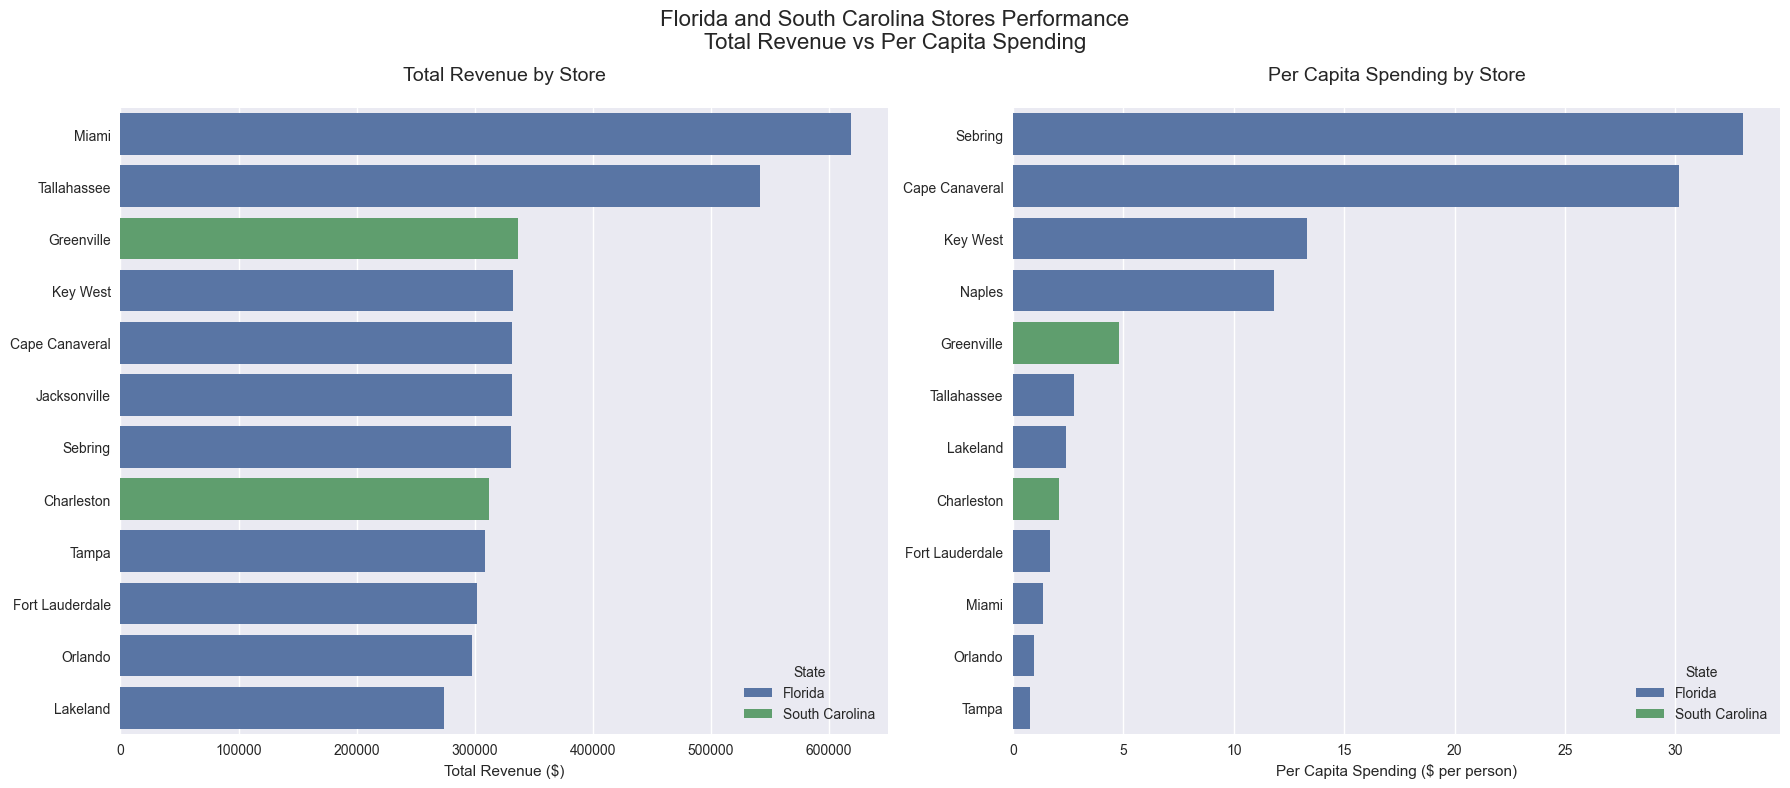

Top Stores by Total Revenue:
     Store Location           State  totalRevenue
5             Miami         Florida     618846.25
9       Tallahassee         Florida     541670.66
12       Greenville  South Carolina     337002.00
3          Key West         Florida     332620.43
0    Cape Canaveral         Florida     331956.13
2      Jacksonville         Florida     331667.08
8           Sebring         Florida     330848.14
11       Charleston  South Carolina     311810.56
10            Tampa         Florida     308979.01
1   Fort Lauderdale         Florida     302270.07

Top Stores by Per Capita Spending:
     Store Location           State  perCapitaSpending  totalRevenue  \
8           Sebring         Florida          33.084814     330848.14   
0    Cape Canaveral         Florida          30.177830     331956.13   
3          Key West         Florida          13.304817     332620.43   
6            Naples         Florida          11.800129     259602.83   
12       Greenville  Sout

In [245]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# left subplot: total revenue
topRevenue = storeSummary.sort_values('totalRevenue', ascending=False).head(12)
sns.barplot(data=topRevenue, x='totalRevenue', y='Store Location', hue='State', ax=axes[0])
axes[0].set_title('Total Revenue by Store', fontsize=14, pad=20)
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_ylabel('')

# right subplot: per capita spending
storeSummary['perCapitaSpending'] = storeSummary['totalRevenue'] / storeSummary['population']
topPerCapita = storeSummary.sort_values('perCapitaSpending', ascending=False).head(12)
sns.barplot(data=topPerCapita, x='perCapitaSpending', y='Store Location', hue='State',ax=axes[1])

axes[1].set_title('Per Capita Spending by Store', fontsize=14, pad=20)
axes[1].set_xlabel('Per Capita Spending ($ per person)')
axes[1].set_ylabel('')

plt.suptitle('Florida and South Carolina Stores Performance\nTotal Revenue vs Per Capita Spending', fontsize=16)
plt.tight_layout()
plt.show()

#top stores in table format
print("Top Stores by Total Revenue:")
print(storeSummary.sort_values('totalRevenue', ascending=False)[['Store Location', 'State', 'totalRevenue']].head(10))

print("\nTop Stores by Per Capita Spending:")
print(storeSummary.sort_values('perCapitaSpending', ascending=False)[['Store Location', 'State', 'perCapitaSpending', 'totalRevenue', 'population']].head(10))

Key Observation: 
Per capita spending in South Carolina locations are better than most existing Florida locations

Expansions should be focused into South Carolina region especially in locations such as Columbia (population close to Charleston size), Rock Hill, Summerville, and Goose Creek.


Suggestions:
Focus on High Per Capita Markets: Sebring, Cape Canaveral, Key West



### 4. Top Customers by RewardsID

In [246]:
# combine sales by State and RewardsID
topCustomers = (assignedSales[assignedSales['RewardsID'].notna()].groupby(['State', 'RewardsID'])['Sale Amount'].sum().reset_index()) 

#merge customer list for names
topCustomers = topCustomers.merge(customerList[['cust_id', 'name']], left_on='RewardsID',right_on='cust_id',how='left') # 'cust_id' matches 'RewardsID' - this is the part that decided to blow up on me
topCustomers.drop(columns=['cust_id'], inplace=True)
topCustomers = topCustomers.sort_values(['State', 'Sale Amount'], ascending=[True, False]).head(10)



print("Top Customers by Rewards ID (with names):")
display(topCustomers[['State', 'name', 'RewardsID', 'Sale Amount']])

Top Customers by Rewards ID (with names):


,State,name,RewardsID,Sale Amount
45,Florida,Stanley H.,47.0,4954.99
257,Florida,Todd Chavez,259.0,4549.16
188,Florida,Huck,190.0,4415.78
333,Florida,John Locke,335.0,3631.94
162,Florida,Dr. Ray Flemming,164.0,3535.88
416,Florida,Ernie,418.0,3387.58
54,Florida,Leslie Knope,56.0,3355.68
141,Florida,Billy Abbott,143.0,3325.45
210,Florida,Geoffrey,212.0,3225.15
213,Florida,Lisa W.,215.0,3204.56


### 5. Transactions and Revenue by Product Category

In [247]:
# this annoys me less
products = pd.read_csv('Products.csv')
productCategories = pd.read_csv('ProductCategories.csv')

# merge sales and product category info
salesEnriched = assignedSales.merge(products[['Prod Num', 'CategoryID']], on='Prod Num', how='left')

salesEnriched = salesEnriched.merge(productCategories[['CategoryID', 'Category']], on='CategoryID', how='left')

# monthly category split
monthlyByCategory = salesEnriched.groupby(['State', 'YearMonth', 'Category']).agg(transactions=('Sale Amount', 'count'),revenue=('Sale Amount', 'sum')).reset_index()

print("Monthly Transactions and Revenue by Category:")
display(monthlyByCategory.head(20))

# top categories by revenue
topCategories = salesEnriched.groupby('Category')['Sale Amount'].sum().sort_values(ascending=False)
print("\nTop Categories by Revenue:")
display(topCategories)

Monthly Transactions and Revenue by Category:


,State,YearMonth,Category,transactions,revenue
0,Florida,2022-01,Apparel and Merchandise,528,15845.52
1,Florida,2022-01,Art Supplies,693,21940.38
2,Florida,2022-01,Books (General),80,2212.40
3,Florida,2022-01,Stationery and Supplies,759,7365.38
4,Florida,2022-01,Technology & Accessories,525,228610.83
5,Florida,2022-01,Textbooks,671,113160.41
6,Florida,2022-02,Apparel and Merchandise,488,16164.64
7,Florida,2022-02,Art Supplies,671,20523.47
8,Florida,2022-02,Books (General),144,3941.28
9,Florida,2022-02,Stationery and Supplies,792,9201.28



Top Categories by Revenue:


Category
Technology & Accessories    22653956.15
Textbooks                    8910314.16
Art Supplies                 1886132.60
Apparel and Merchandise      1688325.92
Stationery and Supplies       772758.14
Books (General)               319736.08
Name: Sale Amount, dtype: float64

As with last months assessment Technology and Accessories continues to be our biggest boon, sales has been increasing and has had jumpss in revenue by as much as 20,000 in a single month.


## Marketing Recommendation for Next Quarter

**Key Findings:**
- Florida generally outperforms South Carolina in total revenue.
- Technology and Accessories is the strongest category across both territories.
- South Carolina has high transaction volume in Textbooks and Art Supplies but lower revenue per transaction.

**Recommendation:**
Focus marketing efforts on **Technology products** (laptops, tablets, headphones) in both territories, with special emphasis on South Carolina. Run targeted promotions and loyalty programs for RewardsID customers. Prioritize top stores for in store events. This strategy should drive both immediate revenue and long term customer growth.

# 1. Segment Stores into 4 Performance Categories



### Stars
- High Revenue High Per Capita
- Protect and Invest heavily (more inventory, marketing, staff)


### Cash Cows
 - High Revenue + Low/Medium Per Capita
 - Maintain efficiency, focus on volume and cost control


### Hidden Gems
 - Lower Revenue + High Per Capita
 - Aggressive growth - expand footprint, add events


### Underperformers
 - Low Revenue + Low Per Capita
 - Review viability - optimize, reduce costs, or consider closure


# 2. Priority Actions by Metric


### For High Total Revenue Stores (Jacksonville, Miami, Orlando, etc.):
- Treat them as strategic anchors - ensure they never run out of high demand items (laptops, textbooks).
- Increase marketing spend and run large scale back to school campaigns.
- Use them as test locations for new products and pricing strategies.

### For High Per Capita Spending Stores (affluent/tourist/college towns):
These are your most valuable customers per person - focus on loyalty and retention.

- Strengthen the Rewards program and SMS marketing (target rewards members).
- Offer premium bundles and personalized recommendations.
- Consider store upgrades or experiential elements (tech demo zones, study lounges).


# Store Performance Optimization:

Based on store-level metrics (total revenue and per‑capita sales), the following initiatives are recommended to reallocate resources, refine product strategy, optimize the store footprint, enhance marketing, and improve operations.



## 1. Resource Reallocation

- Shift **marketing budget**, **best staff**, and **prime inventory** toward the top‑performing stores in **both metrics** (high total revenue **and** high per capita sales).
- Reduce support for **chronically low‑performing locations** (ex. lower ad spend, transfer staff, reduce shelf space).



## 2. Product Strategy

- **Push Technology Accessories** (especially Apple, Dell, headphones, chargers) in **high per capita stores** - these categories drive higher transaction values (AOV).



## 3. Expansion and Optimization

- Look for **expansion opportunities** in cities with **high per capita** but **currently low total revenue** - potential underserved markets.
- Evaluate **closing or converting** the weakest 2-3 stores into:
  - Online fulfillment points
  - Smaller kiosks (to reduce fixed costs while maintaining a presence).



## 4. Marketing and Customer Focus

- Run **localized campaigns** in high per‑capita cities (targeted social ads, local events, etc.).
- **Leverage customer data** to target **students, faculty, and alumni** more effectively (ex. email domains, CRM attributes).
- Create a **“High Spender” loyalty tier** with exclusive perks (early access, free expedited shipping, members only discounts).



## 5. Operational Improvements

- **Benchmark staffing and inventory turnover** between high vs. low per‑capita stores to identify best practices.
- **Train store teams** in high AOV techniques:
  - Bundling
  - Upselling tech products
  - Suggesting relevant accessories



## Next Steps

1. **Data collection** - Ensure store level revenue, per capita sales, staffing, and inventory turnover are regularly updated.
2. **Pilot program** - Test changes in 2-3 top stores and 2-3 low stores before company wide rollout.
3. **Measure impact** - Track KPIs monthly (revenue, AOV, traffic, customer lifetime value).
4. **Iterate** - Adjust allocations based on real time performance data.

kpi is Key performance indicator and aov is Average order value for the peer reviewers